***
# Homework 6: numpy and matplotlib

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten.

**Date:** March 8th, 2024
***

In [51]:
import functools
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt

## 1.) Warmup: Around the Semicircular Law (3 points, spent $\approx$ )

**The (comparatively) young field of random matrix theory (RMT) concerns the behavior of certain matrices with independent random entries. A landmark result in RMT concerns the behavior of the eigenvalues of a random symmetric matrix with normal entries. Under the proper scaling, the joint distribution of the eigenvalues of such a matrix follows the *Wigner semicircular distribution*, which has density**

$$ f(x) = 
\begin{cases} 
\frac{\sqrt{4 - x^2}}{2\pi} & \text{If}\;-2 \le x \le 2\\
0 & \text{Otherwise}
\end{cases} \quad \quad (1)$$

**That is, a symmetric matrix with random normal entries will have eigenvalues whose histogram looks more and more like a semicircle of radius $2$ as n increases to $\infty$. In particular, define a matrix-valued random variable $Z \in \mathbb{R}^{n \times n}$ by generating $Z_{ij}$ iid normal with mean $0$ and variance $\frac{1}{n}$ for all $1 \le i \le j \le n$, and set $Z_{ji} = Z_{ij}$ for $1 \le j \le i \le n$. Then the matrix $Z \in \mathbb{R}^{n \times n}$ is called a *Wigner matrix*.**

**Define a function `wigner_density` that takes a single number (integer or float) as its input and returns a float as its output, given by the value of the semicircular density evaluated at the input. That is, for a number $x$, `wigner_density(x)` should return $f(x)$, where $f$ is defined above in Equation (1). You do not need to perform any error checking in this function, but note that your function should operate equally well on Python ints/floats and on numpy ints/floats, and you should be able to accomplish this without checking the type of the input. Use the `numpy.sqrt` function for the square root, NOT the Python `math.sqrt` function.**

In [52]:
def wigner_density(x):
    if -2 <= x and x <= 2:
        return np.sqrt(4 - x**2) / (2 * (np.pi))
    else:
        return 0

In [53]:
x = np.linspace(-3, 3, 1000)
y = list(map(lambda xi: wigner_density(xi), x))

**Define a function `generate_wigner` that takes a single positive integer `n` as its argument and returns a random $n$-by-$n$ Wigner matrix. Your function should raise an appropriate error in the event that the input is not a positive integer. The output of your function may be either a `numpy` matrix or simply a `numpy` array, though I would recommend the former, for ease of use in the next sub-problem. You can cast a 2-dimensional `numpy` array a to a matrix by writing `np.matrix(a)`.** 

**Hint: depending on the solution you choose, you may find the `numpy.triu` and `numpy.tril` functions to be useful. A different solution makes use of the `scipy.spatial.distance.squareform` function.**

In [54]:
def generate_wigner(n):

    if not isinstance(n, (int, )):
        raise TypeError(f'n = {n} must be of type int.') # raises error when n is not of type int.
    if n <= 0:
        raise ValueError(f'n = {n} must be a positive integer.') # raises error when n is not a positive integer.
    
    Z = np.zeros((n, n)) # np.zeros((n, n)) gives us a (n-by-n) 2-dimensional numpy array of zeros.
    
    for i in range(n):
        for j in range(i, n):
            sample = np.random.default_rng().normal(loc = 0, scale = 1/n, size = 1) # get a single sample from a normal distribution
            Z[i, j] = sample[0]
            Z[j, i] = sample[0]
            
    return Z

In [55]:
arr = [100, 200, 500, 1000]
wigner_matrices = list(map(lambda n: generate_wigner(n), arr))

**The RMT result referenced above states that the joint distribution of the eigenvalues of a random Wigner matrix converges to the semicircular law. Write a function `get_spectrum` that takes a numpy matrix or 2-dimensional numpy array and returns a numpy array of its eigenvalues in *non-decreasing* order. You do not need to perform any error checking for this function.**

In [56]:
def get_spectrum(Z):
    return np.sort(np.linalg.eigh(Z)[0])

In [57]:
wigner_eigenvalues = list(map(lambda Z: get_spectrum(Z), wigner_matrices))
minimum = [min(eigenvalue) for eigenvalue in wigner_eigenvalues]
maximum = [max(eigenvalue) for eigenvalue in wigner_eigenvalues]

In [58]:
scaled_max = 2
scaled_min = -2
scaled_wigner_eigenvalue = []
for idx, eigenvalue in enumerate(wigner_eigenvalues):
    scaled_eigenvalue = ((eigenvalue - minimum[idx]) / (maximum[idx] - minimum[idx])) * (scaled_max - scaled_min) + scaled_min
    scaled_wigner_eigenvalue.append(scaled_eigenvalue)

**Create a plot with four subplots, arranged vertically, each showing a (normalized) histogram, in blue, of the eigenvalues of a random $n$-by-$n$ Wigner matrix for $n = 100, 200, 500$ and $1000$. In each subplot, overlay a red curve indicating the density of the semicircular law, as defined in (1). Save this plot in a `.png` file called `wigner_plots.png` and include it in your submission.**

**Hint: depending on how you implemented wigner_density above, you may find the numpy.vectorize function helpful.**

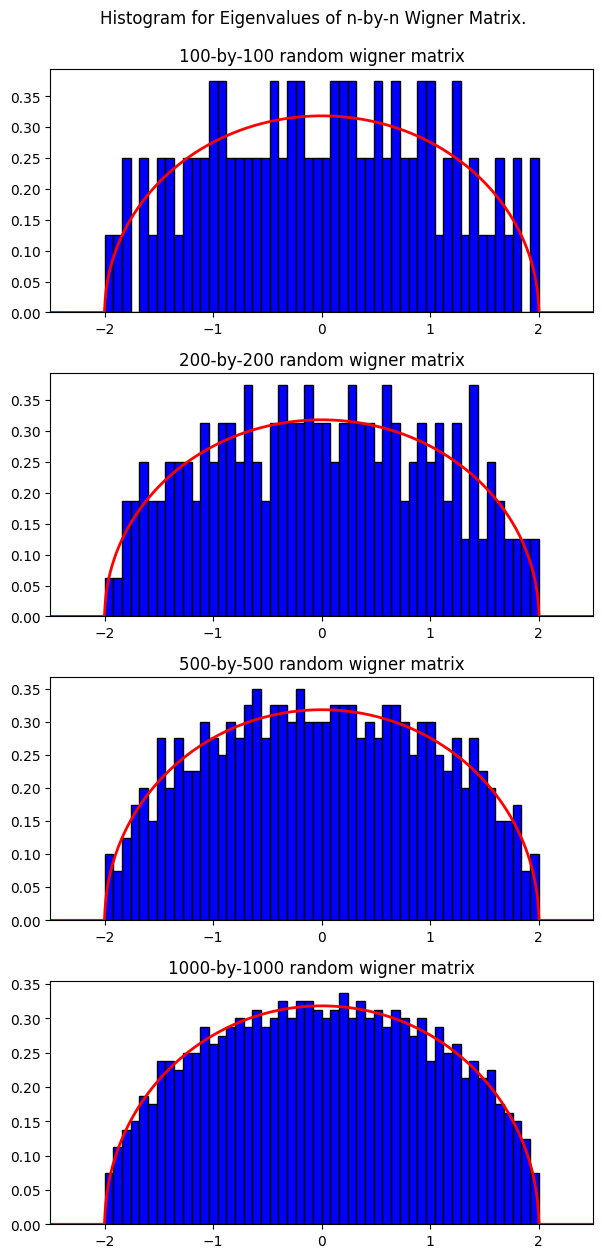

In [66]:
fig, axs = plt.subplots(len(arr), figsize = (7, 15))

for i in range(len(arr)):

    axs[i].hist(scaled_wigner_eigenvalue[i], 
                density = True,
                bins = 50,
                color = 'blue',
                edgecolor = 'black',
                alpha = 1)
    axs[i].plot(x, y, color = 'red', linewidth = 2)
    axs[i].set_xlim([-2.5, 2.5])
    axs[i].set_title(f'{arr[i]}-by-{arr[i]} random wigner matrix')

fig.suptitle('Histogram for Eigenvalues of n-by-n Wigner Matrix.', y = 0.92)
plt.subplots_adjust(hspace = 0.25)
plt.show()